# N-Gram Analysis

## 1. Setup & Installation

In [97]:
# Install required libraries
!pip install nltk Sastrawi matplotlib seaborn pandas -q

In [98]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Load Dataset

In [99]:
path = "dataset.csv"
df = pd.read_csv(path)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print()
df.head()

Dataset shape: 200 rows, 5 columns
Columns: ['No', 'URL', 'Judul', 'Konten', 'Sentiment']



,No,URL,Judul,Konten,Sentiment
0,1,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive
1,2,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive
2,3,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive
3,4,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative
4,5,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive


In [100]:
# Quick data overview
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Total articles   : {len(df)}")
print(f"Missing 'Konten' : {df['Konten'].isna().sum()}")
print(f"Sentiment values : {df['Sentiment'].unique()}")
print()

# Show all article titles for reference
print("=" * 60)
print("ARTICLE LIST")
print("=" * 60)
for idx, row in df.iterrows():
    print(f"  [{row['No']}] {row['Judul'][:80]}")

DATASET INFO
Total articles   : 200
Missing 'Konten' : 0
Sentiment values : <StringArray>
['Positive', 'Negative', 'Netral', nan]
Length: 4, dtype: str

ARTICLE LIST
  [1] Trump Sebar Exceutive Order: Emang Semengerikan Apa Buat Indonesia? - CNBC Indon
  [2] Alasan Rupiah 'Berpesta' di Pelantikan Trump, Dolar Bisa Rp15.000an? - CNBC Indo
  [3] Trump Beri Kabar Baik, Saatnya Menunggu Dolar Eksportir Balik ke RI - CNBC Indon
  [4] IHSG Merah Lagi, Begini Penjelasan dari Analis! - CNBC Indonesia
  [5] Bernstein: Bitcoin Bisa Naik 2x Lipat! Target $200K? - INDODAX
  [6] Penjelasan Lengkap Prabowo Respons Kebijakan Terbaru Tarif Trump AS - CNBC Indon
  [7] IHSG Tertekan, BPJS Ketenagakerjaan dan Taspen Tambah Portofolio di Pasar Saham 
  [8] Dampak Penangguhan Tarif Trump: Bitcoin Naik Pesat - INDODAX
  [9] Indonesia Perluas Akses Pasar Dunia, Mengurangi Tekanan Tarif Trump - Bisnis.com
  [10] Catat! Relaksasi TKDN untuk Produk AS terkait Barang IT dan Telko - CNBC Indones
  [11] Indonesia-

## 3. Article Selection (Adjustable)

You can choose which articles to analyze in **three ways**:
1. By specific article number(s)
2. By sentiment label
3. All articles at once

Change the `SELECTION_MODE` and its parameters below.

In [101]:
# ADJUST THIS: Choose your selection mode
SELECTION_MODE = "by_number"  # Options: "by_number", "by_sentiment", "all"

# --- If SELECTION_MODE = "by_number" ---
ARTICLE_NUMBERS = [9]  # <-- Change these numbers

# --- If SELECTION_MODE = "by_sentiment" ---
TARGET_SENTIMENT = "positif"  # <-- Change this label

if SELECTION_MODE == "by_number":
    selected_df = df[df['No'].isin(ARTICLE_NUMBERS)].copy()
    print(f"Selected {len(selected_df)} article(s) by number: {ARTICLE_NUMBERS}")

elif SELECTION_MODE == "by_sentiment":
    selected_df = df[df['Sentiment'].str.lower() == TARGET_SENTIMENT.lower()].copy()
    print(f"Selected {len(selected_df)} article(s) with sentiment: '{TARGET_SENTIMENT}'")

elif SELECTION_MODE == "all":
    selected_df = df.copy()
    print(f"Selected ALL {len(selected_df)} articles")

else:
    raise ValueError(f"Invalid SELECTION_MODE: '{SELECTION_MODE}'. Use 'by_number', 'by_sentiment', or 'all'.")

# Drop rows with empty content
selected_df = selected_df.dropna(subset=['Konten'])
print(f"Articles with valid content: {len(selected_df)}")
print()

# Show selected titles
for idx, row in selected_df.iterrows():
    print(f"  [{row['No']}] {row['Judul'][:80]}")

Selected 1 article(s) by number: [9]
Articles with valid content: 1

  [9] Indonesia Perluas Akses Pasar Dunia, Mengurangi Tekanan Tarif Trump - Bisnis.com


## 4. Text Preprocessing (Bahasa Indonesia)

Preprocessing steps:
1. **Lowercase** all text
2. **Remove URLs, HTML tags, numbers, punctuation**
3. **Remove Indonesian stopwords** using Sastrawi
4. **Tokenize** into individual words
5. *(Optional)* **Stemming** using Sastrawi Indonesian stemmer

Sastrawi is used because it is specifically built for Bahasa Indonesia, unlike NLTK's default English stopwords.

In [102]:
# ============================================================
# ADJUST THIS: Toggle stemming on/off
# Stemming reduces words to their root form, e.g.:
#   "membangun" -> "bangun", "pemerintahan" -> "perintah"
# Set to False if you want to keep original word forms.
# ============================================================
USE_STEMMING = False  # Set True to enable stemming

# Initialize Sastrawi tools
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stopword_factory.get_stop_words())

# Add custom stopwords if needed (common filler words in articles)
custom_stopwords = {
    'yang', 'dan', 'di', 'dari', 'untuk', 'pada', 'dengan',
    'ini', 'itu', 'ke', 'dalam', 'adalah', 'juga', 'tidak',
    'akan', 'ada', 'atau', 'bisa', 'sudah', 'lebih', 'oleh',
    'hal', 'saat', 'dapat', 'telah', 'mereka', 'saya', 'kami',
    'kita', 'hanya', 'seperti', 'tentang', 'antara', 'lain',
    'maka', 'jika', 'bagi', 'pun', 'lagi', 'masih', 'ia',
    'dia', 'anda', 'kata', 'ujar', 'ucap', 'tutur', 'sebut'
}
all_stopwords = indonesian_stopwords.union(custom_stopwords)

if USE_STEMMING:
    stemmer_factory = StemmerFactory()
    stemmer = stemmer_factory.createStemmer()
    print("Stemmer initialized (this may take a moment).")

print(f"Total stopwords loaded: {len(all_stopwords)}")

Total stopwords loaded: 129


In [103]:
def preprocess_text(text):
    """
    Full preprocessing pipeline for Bahasa Indonesia text.

    Steps:
    1. Lowercase
    2. Remove URLs
    3. Remove HTML tags
    4. Remove numbers
    5. Remove punctuation and special characters
    6. Tokenize
    7. Remove stopwords
    8. Remove short tokens (length < 3)
    9. (Optional) Stemming

    Args:
        text (str): Raw article text

    Returns:
        list: List of cleaned tokens
    """
    if not isinstance(text, str):
        return []

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # Step 3: Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Step 4: Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Step 5: Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 6: Tokenize
    tokens = word_tokenize(text)

    # Step 7: Remove stopwords
    tokens = [t for t in tokens if t not in all_stopwords]

    # Step 8: Remove short tokens (likely noise)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 9: Optional stemming
    if USE_STEMMING:
        tokens = [stemmer.stem(t) for t in tokens]

    return tokens


# Apply preprocessing to selected articles
print("Preprocessing articles...")
selected_df['tokens'] = selected_df['Konten'].apply(preprocess_text)
selected_df['token_count'] = selected_df['tokens'].apply(len)

print("Done!")
print()

# Show token counts per article
for idx, row in selected_df.iterrows():
    print(f"  [{row['No']}] {row['Judul']} -> {row['token_count']} tokens")
    print(row["Konten"])

Preprocessing articles...
Done!

  [9] Indonesia Perluas Akses Pasar Dunia, Mengurangi Tekanan Tarif Trump - Bisnis.com -> 119 tokens
Bisnis.com, JAKARTA - Kebijakan tarif Trump membuat Indonesia perlu memperluas pasar internasional. Apalagi kontribusi Amerika Serikat terhadap perdagangan Tanah Air tidak terlalu besar, yaitu 17%. 

Hal itu juga dikuatkan oleh data Badan Pusat Statistik (BPS). Berdasarkan publikasinya, ekspor nonmigas ke kawasan Afrika dan Asia Selatan meningkat masing-masing sebesar 12,5% dan 9,3% pada kuartal pertama 2024 dibandingkan periode yang sama tahun sebelumnya. 

Sementara Kementerian Koordinator Bidang Perekonomian mencatat setidaknya ada 10 organisasi internasional yang menjadi peluang mitra strategis. 

Di saat yang sama, Indonesia bisa menyiapkan diri dengan matang karena Presiden AS Donald Trump menunda kebijakan tarif timbal balik. 

Ketua Umum Gabungan Perusahaan Ekspor Indonesia (GPEI) Benny Soetrisno mengatakan kesempatan Indonesia untuk mengirim bar

In [104]:
# Preview tokens from the first selected article
first_article = selected_df.iloc[0]
print(f"Preview tokens from article [{first_article['No']}]:")
print(first_article['tokens'][:30])
print(f"... (total: {first_article['token_count']} tokens)")

Preview tokens from article [9]:
['bisnis', 'com', 'jakarta', 'kebijakan', 'tarif', 'trump', 'membuat', 'indonesia', 'perlu', 'memperluas', 'pasar', 'internasional', 'kontribusi', 'amerika', 'serikat', 'perdagangan', 'tanah', 'air', 'terlalu', 'besar', 'dikuatkan', 'data', 'badan', 'pusat', 'statistik', 'bps', 'berdasarkan', 'publikasinya', 'ekspor', 'nonmigas']
... (total: 119 tokens)


## 5. N-Gram Generation

**What is an N-Gram?**

An N-gram is a contiguous sequence of N words from a text. For example, given the sentence "saya suka makan nasi goreng":

| N | Name    | Output                                                        |
|---|---------|---------------------------------------------------------------|
| 1 | Unigram | ["saya", "suka", "makan", "nasi", "goreng"]                   |
| 2 | Bigram  | [("saya","suka"), ("suka","makan"), ("makan","nasi"), ("nasi","goreng")] |
| 3 | Trigram | [("saya","suka","makan"), ("suka","makan","nasi"), ("makan","nasi","goreng")] |

We generate all three types below.

In [105]:
def generate_ngrams(tokens, n):
    """
    Generate n-grams from a list of tokens.

    Args:
        tokens (list): List of word tokens
        n (int): The 'n' in n-gram (1=unigram, 2=bigram, 3=trigram)

    Returns:
        list: List of n-gram tuples
    """
    return list(ngrams(tokens, n))


# Combine all tokens from selected articles into one list
all_tokens = []
for tokens in selected_df['tokens']:
    all_tokens.extend(tokens)

print(f"Total combined tokens: {len(all_tokens)}")
print()

# Generate unigrams, bigrams, and trigrams
unigrams = generate_ngrams(all_tokens, 1)
bigrams  = generate_ngrams(all_tokens, 2)
trigrams = generate_ngrams(all_tokens, 3)

print(f"Unigrams generated: {len(unigrams)}")
print(f"Bigrams generated : {len(bigrams)}")
print(f"Trigrams generated: {len(trigrams)}")

Total combined tokens: 119

Unigrams generated: 119
Bigrams generated : 118
Trigrams generated: 117


---
## 6. N-Gram Frequency Analysis

We count how often each n-gram appears and rank them by frequency.

In [106]:
# ============================================================
# ADJUST THIS: How many top n-grams to display
# ============================================================
TOP_N = 20  # Show top 20 most frequent n-grams

# Count frequencies
unigram_freq = Counter(unigrams)
bigram_freq  = Counter(bigrams)
trigram_freq = Counter(trigrams)

# Convert to DataFrames for clean display
def freq_to_dataframe(freq_counter, n_label):
    """
    Convert a Counter of n-grams into a sorted DataFrame.

    Args:
        freq_counter (Counter): Frequency counter of n-grams
        n_label (str): Label for the n-gram type

    Returns:
        pd.DataFrame: Sorted DataFrame with columns [n-gram, frequency]
    """
    items = freq_counter.most_common(TOP_N)
    df_freq = pd.DataFrame(items, columns=[n_label, 'Frequency'])
    # Join tuples into readable strings
    df_freq[n_label] = df_freq[n_label].apply(lambda x: ' '.join(x))
    df_freq.index = range(1, len(df_freq) + 1)  # Start index at 1
    df_freq.index.name = 'Rank'
    return df_freq


df_unigrams = freq_to_dataframe(unigram_freq, 'Unigram')
df_bigrams  = freq_to_dataframe(bigram_freq, 'Bigram')
df_trigrams = freq_to_dataframe(trigram_freq, 'Trigram')

In [107]:
print("=" * 40)
print(f"TOP {TOP_N} UNIGRAMS")
print("=" * 40)
print(df_unigrams.to_string())

TOP 20 UNIGRAMS
            Unigram  Frequency
Rank                          
1         indonesia          5
2             tarif          4
3         kebijakan          3
4            ekspor          3
5            barang          3
6             trump          2
7     internasional          2
8             tanah          2
9               air          2
10           masing          2
11             sama          2
12           bisnis          1
13              com          1
14          jakarta          1
15          membuat          1
16            perlu          1
17       memperluas          1
18            pasar          1
19       kontribusi          1
20          amerika          1


In [108]:
print("=" * 40)
print(f"TOP {TOP_N} BIGRAMS")
print("=" * 40)
print(df_bigrams.to_string())

TOP 20 BIGRAMS
                        Bigram  Frequency
Rank                                     
1              kebijakan tarif          3
2                    tanah air          2
3                   bisnis com          1
4                  com jakarta          1
5            jakarta kebijakan          1
6                  tarif trump          1
7                trump membuat          1
8            membuat indonesia          1
9              indonesia perlu          1
10            perlu memperluas          1
11            memperluas pasar          1
12         pasar internasional          1
13    internasional kontribusi          1
14          kontribusi amerika          1
15             amerika serikat          1
16         serikat perdagangan          1
17           perdagangan tanah          1
18                 air terlalu          1
19               terlalu besar          1
20             besar dikuatkan          1


In [109]:
print("=" * 40)
print(f"TOP {TOP_N} TRIGRAMS")
print("=" * 40)
print(df_trigrams.to_string())

TOP 20 TRIGRAMS
                               Trigram  Frequency
Rank                                             
1                   bisnis com jakarta          1
2                com jakarta kebijakan          1
3              jakarta kebijakan tarif          1
4                kebijakan tarif trump          1
5                  tarif trump membuat          1
6              trump membuat indonesia          1
7              membuat indonesia perlu          1
8           indonesia perlu memperluas          1
9               perlu memperluas pasar          1
10      memperluas pasar internasional          1
11      pasar internasional kontribusi          1
12    internasional kontribusi amerika          1
13          kontribusi amerika serikat          1
14         amerika serikat perdagangan          1
15           serikat perdagangan tanah          1
16               perdagangan tanah air          1
17                   tanah air terlalu          1
18                   air terlalu b

## 7. Visualization

In [110]:
def plot_ngram(df_freq, n_label, color_palette, top_k=15):
    """
    Plot a horizontal bar chart for n-gram frequencies.

    Args:
        df_freq (pd.DataFrame): DataFrame with n-gram and frequency columns
        n_label (str): Column name for the n-gram (used as title)
        color_palette (str): Seaborn color palette name
        top_k (int): Number of top n-grams to plot
    """
    data = df_freq.head(top_k).iloc[::-1]  # Reverse for horizontal bar

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette(color_palette, len(data))

    ax.barh(data[n_label], data['Frequency'], color=colors)
    ax.set_xlabel('Frequency', fontsize=12)
    ax.set_ylabel(n_label, fontsize=12)
    ax.set_title(f'Top {top_k} Most Frequent {n_label}s', fontsize=14, fontweight='bold')

    # Add count labels on bars
    for i, (val, name) in enumerate(zip(data['Frequency'], data[n_label])):
        ax.text(val + 0.3, i, str(val), va='center', fontsize=10)

    plt.tight_layout()
    plt.show()


# ============================================================
# ADJUST THIS: Number of n-grams to plot
# ============================================================
PLOT_TOP_K = 15

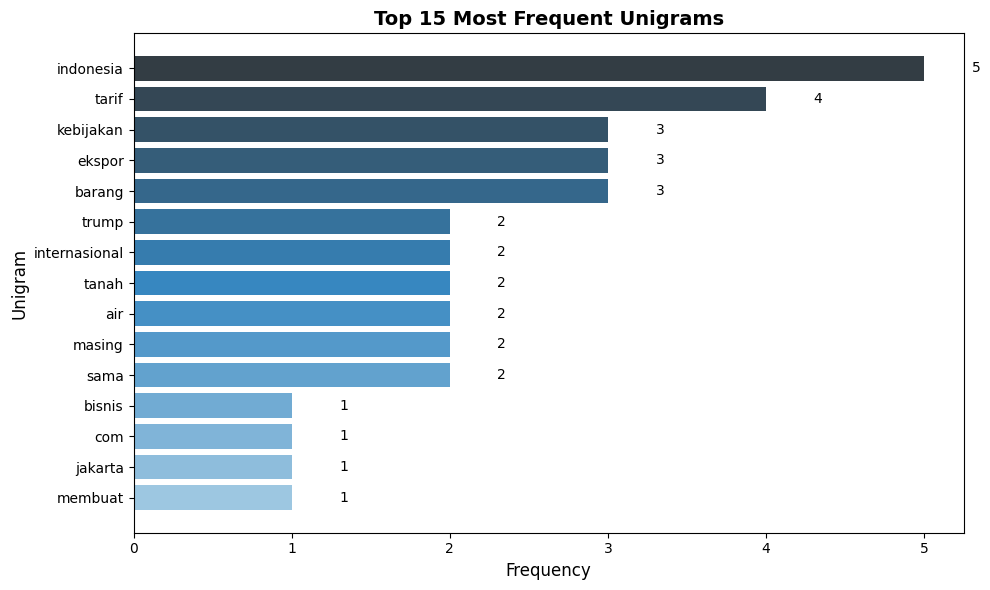

In [111]:
plot_ngram(df_unigrams, 'Unigram', 'Blues_d', PLOT_TOP_K)

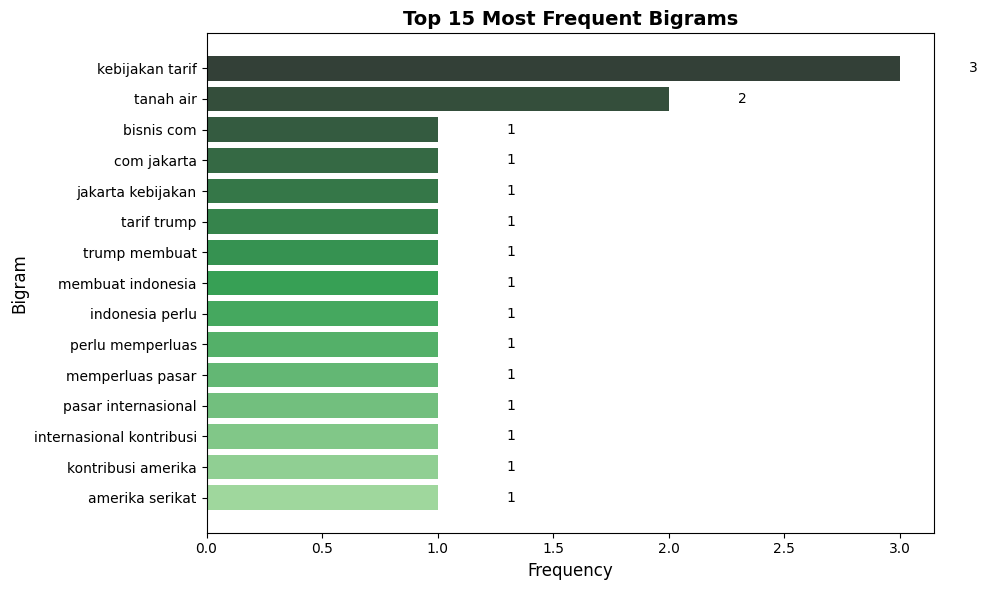

In [112]:
plot_ngram(df_bigrams, 'Bigram', 'Greens_d', PLOT_TOP_K)

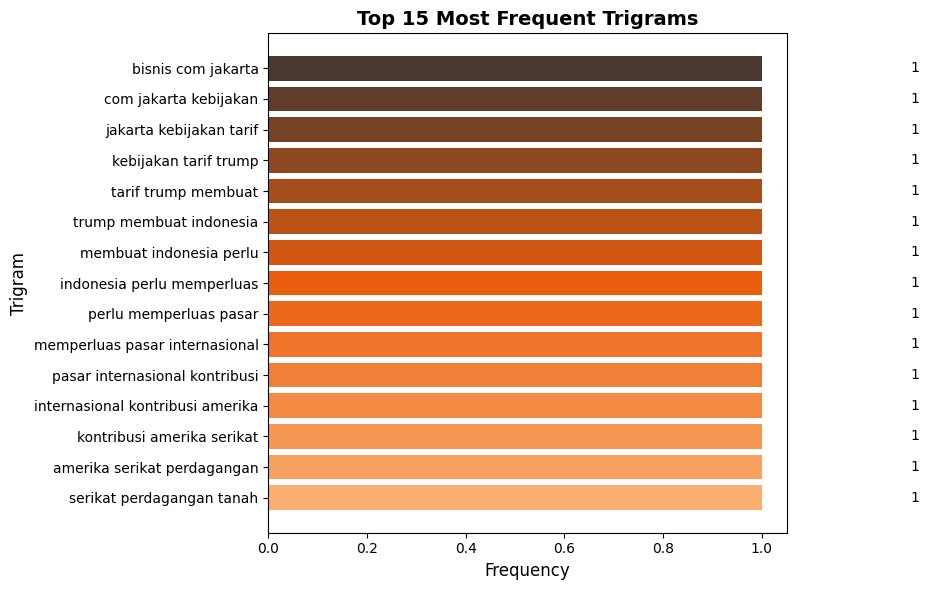

In [113]:
plot_ngram(df_trigrams, 'Trigram', 'Oranges_d', PLOT_TOP_K)

### 7.1 Combined Overview Chart

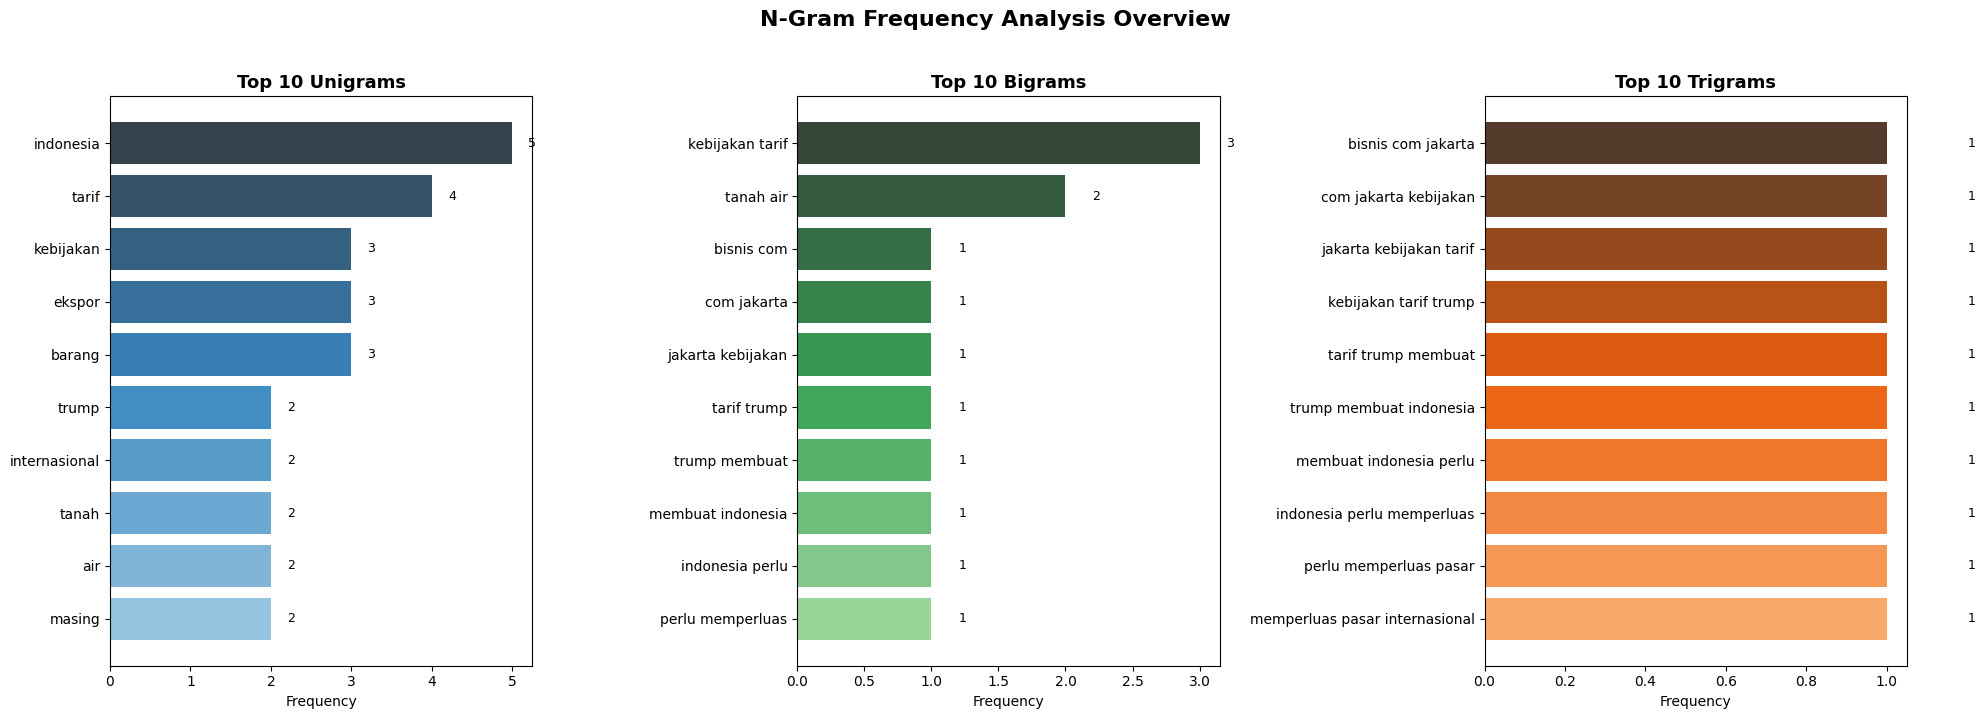

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

datasets = [
    (df_unigrams, 'Unigram', 'Blues_d'),
    (df_bigrams, 'Bigram', 'Greens_d'),
    (df_trigrams, 'Trigram', 'Oranges_d')
]

for ax, (df_freq, label, palette) in zip(axes, datasets):
    top_10 = df_freq.head(10).iloc[::-1]
    colors = sns.color_palette(palette, len(top_10))
    ax.barh(top_10[label], top_10['Frequency'], color=colors)
    ax.set_title(f'Top 10 {label}s', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')

    for i, val in enumerate(top_10['Frequency']):
        ax.text(val + 0.2, i, str(val), va='center', fontsize=9)

plt.suptitle('N-Gram Frequency Analysis Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Per-Article N-Gram Comparison (Optional)

If you selected multiple articles, this section shows the top bigrams for each article individually, so you can compare patterns across articles.

In [115]:
if len(selected_df) > 1:
    print("Per-article top 5 bigrams:")
    print("=" * 60)
    for idx, row in selected_df.iterrows():
        article_bigrams = generate_ngrams(row['tokens'], 2)
        article_bigram_freq = Counter(article_bigrams).most_common(5)
        print(f"\nArticle [{row['No']}]: {row['Judul'][:60]}")
        for bg, count in article_bigram_freq:
            print(f"    {' '.join(bg):30s}  ({count}x)")
else:
    print("Only one article selected. Skipping per-article comparison.")

Only one article selected. Skipping per-article comparison.


In [116]:
print("=" * 60)
print("N-GRAM ANALYSIS SUMMARY")
print("=" * 60)
print(f"Articles analyzed      : {len(selected_df)}")
print(f"Total tokens (cleaned) : {len(all_tokens)}")
print(f"Unique unigrams        : {len(unigram_freq)}")
print(f"Unique bigrams         : {len(bigram_freq)}")
print(f"Unique trigrams        : {len(trigram_freq)}")
print(f"Stemming applied       : {USE_STEMMING}")
print(f"Selection mode         : {SELECTION_MODE}")
print()
print("Top 5 Bigrams:")
for bg, count in bigram_freq.most_common(5):
    print(f"    {' '.join(bg):30s}  ({count}x)")

N-GRAM ANALYSIS SUMMARY
Articles analyzed      : 1
Total tokens (cleaned) : 119
Unique unigrams        : 100
Unique bigrams         : 115
Unique trigrams        : 117
Stemming applied       : False
Selection mode         : by_number

Top 5 Bigrams:
    kebijakan tarif                 (3x)
    tanah air                       (2x)
    bisnis com                      (1x)
    com jakarta                     (1x)
    jakarta kebijakan               (1x)
